# 03 - Fine-Tuning with LoRA
Parameter-efficient fine-tuning of ESM-2 using LoRA for pathogen virulence gene functional class classification.

## GoHREP

**Goal:**

Fine-tune both the 150M and 650M ESM-2 variants using LoRA (Low-Rank Adaptation) to classify pathogen virulence gene sequences from PHI-base into 8 functional classes, using 5-fold cross validation to produce reliable performance estimates, and compare against the frozen embedding baselines established in notebook 02 (small: macro F1 0.698 ± 0.019, large: macro F1 0.733 ± 0.016).

**Hypothesis:**

LoRA fine-tuning of ESM-2's attention and feed-forward layers will adapt the encoder's pre-trained representations to better capture functional class-specific sequence signatures, meaningfully improving classification performance over the frozen baseline for both model sizes — particularly for the weaker classes (Secondary metabolite / Biosynthesis, Protease, Secretion system) where frozen embeddings struggle to separate biochemically overlapping sequences. The 650M model will benefit more from fine-tuning in absolute terms due to its richer representational capacity.

**Rationale:**

The frozen embedding baselines demonstrated that ESM-2's pre-trained representations already encode substantial functional class signal, with ~50% of misclassifications having the correct class as the second prediction — indicating genuine boundary ambiguity rather than arbitrary errors. ESM-2 was pre-trained on evolutionary sequence data without any exposure to pathogen-specific functional annotations, meaning its representations are not optimally organised for this classification task. LoRA fine-tuning adapts the encoder's attention mechanisms and feed-forward layers to better separate the 8 functional classes while retaining the general biochemical knowledge encoded during pre-training. Critically, LoRA achieves this with only 0.1–1% of the full parameter count, making fine-tuning feasible on Colab A100 hardware for both model sizes. Class-weighted loss is retained from the baseline to ensure the smaller classes (Protease: 199 sequences, Secretion system: 202 sequences) receive sufficient training signal relative to the larger classes (Transcription factor / Regulator: 1,537 sequences, Kinase / Signalling: 987 sequences). 5-fold cross validation ensures the performance estimates are robust and not fold-dependent, consistent with the baseline evaluation approach.

**Experimental Plan:**

1. **Data loading:** Load saved train and test CSV splits from `data/splits/`. Convert to HuggingFace `Dataset` format for efficient batching with the ESM-2 tokenizer.
2. **Model architecture:** Load both ESM-2 variants, apply LoRA adapters to attention and feed-forward layers using PEFT, and attach the 8-class classification head (640/1280 → 256 → 128 → 8) consistent with the prototyping architecture in notebook 02.
3. **Training configuration:** Configure training with batch size informed by memory profiling in notebook 02, cosine learning rate schedule with warmup, mixed precision (fp16), class-weighted cross-entropy loss, and early stopping.
4. **5-fold cross validation:** Train both model sizes using stratified 5-fold cross validation on the training pool, consistent with the baseline evaluation. Report mean ± std macro F1, per-class F1, and averaged confusion matrices across folds.
5. **Comparison against frozen baseline:** Report per-class and macro F1 improvements over the frozen baseline for both model sizes, identifying which classes benefit most from encoder fine-tuning.
6. **Error analysis:** Evaluate per-class F1, confusion matrices, top-2 prediction analysis, truncation analysis, fragment accuracy (<100 AA), and sequence length–outcome correlation on the best fold, comparing error patterns against the frozen baseline to assess whether LoRA resolves the boundary ambiguities identified in notebook 02.
7. **Model saving:** Save LoRA adapters, classification head weights, and deployment config to Google Cloud Storage for both model sizes. Checkpoints are staged to Colab local scratch and uploaded to GCS to avoid Google Drive storage limits.


# 0 Environment Setup

This section mounts Google Drive and installs dependencies from the GitHub repository.

In [1]:
import yaml
from google.colab import drive
import os

drive.mount('/content/drive')
PROJECT_ROOT = "/content/drive/MyDrive/esm-phi-effector"
os.chdir(PROJECT_ROOT)

# ── GCS Configuration ──────────────────────────────────────────────
# Checkpoints and training artifacts are saved to a Google Cloud
# Storage bucket instead of Drive, to avoid Drive storage limits.
#
# Prerequisites (one-time setup — see Part A of the guide):
#   1. Create a GCP project and enable the Cloud Storage API
#   2. Create a bucket (e.g. esm-phi-checkpoints)
#   3. Create a service account with Storage Object Admin role
#   4. Download the JSON key and upload it as a Colab Secret
#      named GCS_SA_KEY (paste the full JSON string)
#
# Authenticate with the service account key
from google.colab import userdata
import tempfile, json as _json

GCS_BUCKET     = "esm-phi-checkpoints"   # ← change to your bucket name
GCS_PREFIX     = "lora_checkpoints"       # folder inside the bucket

_sa_key_json = userdata.get('GCS_SA_KEY')
_sa_key_file = tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False)
_sa_key_file.write(_sa_key_json)
_sa_key_file.close()
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = _sa_key_file.name

from google.cloud import storage as gcs_storage
_gcs_client = gcs_storage.Client()
_gcs_bucket = _gcs_client.bucket(GCS_BUCKET)
print(f"GCS authenticated — bucket: gs://{GCS_BUCKET}/{GCS_PREFIX}/")

# ── Helper functions for GCS upload / download ──────────────────────
import glob

def upload_dir_to_gcs(local_dir, gcs_prefix):
    """Upload all files in local_dir to gs://BUCKET/gcs_prefix/."""
    for local_path in glob.glob(os.path.join(local_dir, '**', '*'), recursive=True):
        if os.path.isfile(local_path):
            rel = os.path.relpath(local_path, local_dir)
            blob = _gcs_bucket.blob(f"{gcs_prefix}/{rel}")
            blob.upload_from_filename(local_path)
    print(f"  ↑ Uploaded {local_dir} → gs://{GCS_BUCKET}/{gcs_prefix}/")

def download_dir_from_gcs(gcs_prefix, local_dir):
    """Download all blobs under gcs_prefix to local_dir."""
    os.makedirs(local_dir, exist_ok=True)
    blobs = list(_gcs_client.list_blobs(GCS_BUCKET, prefix=gcs_prefix + '/'))
    if not blobs:
        return False
    for blob in blobs:
        rel = os.path.relpath(blob.name, gcs_prefix)
        dest = os.path.join(local_dir, rel)
        os.makedirs(os.path.dirname(dest), exist_ok=True)
        blob.download_to_filename(dest)
    print(f"  ↓ Downloaded gs://{GCS_BUCKET}/{gcs_prefix}/ → {local_dir}")
    return True

def gcs_prefix_exists(gcs_prefix):
    """Check whether any blobs exist under gcs_prefix."""
    return any(True for _ in _gcs_client.list_blobs(GCS_BUCKET, prefix=gcs_prefix + '/', max_results=1))

def upload_file_to_gcs(local_path, gcs_key):
    """Upload a single file."""
    blob = _gcs_bucket.blob(gcs_key)
    blob.upload_from_filename(local_path)

def download_file_from_gcs(gcs_key, local_path):
    """Download a single file. Returns False if not found."""
    blob = _gcs_bucket.blob(gcs_key)
    if not blob.exists():
        return False
    os.makedirs(os.path.dirname(local_path), exist_ok=True)
    blob.download_to_filename(local_path)
    return True

# ── Load config files ──────────────────────────────────────────────
model_config_path    = os.path.join(PROJECT_ROOT, "configs/model_config.yaml")
training_config_path = os.path.join(PROJECT_ROOT, "configs/training_config.yaml")
data_config_path = os.path.join(PROJECT_ROOT, "configs/data_config.yaml")

with open(model_config_path, 'r') as f:
    model_config = yaml.safe_load(f)

with open(training_config_path, 'r') as f:
    training_config = yaml.safe_load(f)

with open(data_config_path, 'r') as f:
    data_config = yaml.safe_load(f)

print("Configs loaded:")
print(f"  Models:   {list(model_config['model']['models'].values())}")
print(f"  Classes:  {model_config['model']['num_classes']}")

Mounted at /content/drive
GCS authenticated — bucket: gs://esm-phi-checkpoints/lora_checkpoints/
Configs loaded:
  Models:   ['facebook/esm2_t30_150M_UR50D', 'facebook/esm2_t33_650M_UR50D']
  Classes:  8


In [2]:
!pip install -q google-cloud-storage

if os.path.exists("requirements.txt"):
    !pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 114.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.0/258.0 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.0/57.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 106.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.3/145.3 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 720.1/720

In [3]:
# Imports
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_class_weight
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModel,
    TrainingArguments, Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)
from peft import LoraConfig, get_peft_model, TaskType
import wandb

print(f"PyTorch version:  {torch.__version__}")
print(f"CUDA available:   {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:              {torch.cuda.get_device_name(0)}")

PyTorch version:  2.10.0+cu128
CUDA available:   True
GPU:              NVIDIA A100-SXM4-40GB


## 1 Data Loading

This section loads the curated train and test CSV splits from data curation, verifies label integrity, and tokenizes sequences for both ESM-2 variants. The key difference from notebook 02 is that tokenization produces padded tensors stored in HuggingFace Dataset format rather than raw sequences, since the Trainer handles batching and forward passes internally. Train/validation splits are generated dynamically via stratified K-fold cross validation during training rather than being pre-split.

In [4]:
# Load curated splits
splits_dir = os.path.join(PROJECT_ROOT, data_config['paths']['splits_dir'])

df_train = pd.read_csv(os.path.join(splits_dir, "train.csv"))
df_test  = pd.read_csv(os.path.join(splits_dir, "test.csv"))

label_mapping = data_config['target_mapping']
idx_to_class  = {v: k for k, v in label_mapping.items()}
class_names   = [idx_to_class[i] for i in range(model_config['model']['num_classes'])]

print(f"Train pool: {len(df_train)} sequences")
print(f"Test:       {len(df_test)} sequences")
print(f"\nLabel mapping: {label_mapping}")

# Verify all classes present
missing = set(df_train['functional_class'].unique()) - set(label_mapping.keys())
assert not missing, f"Classes missing from label mapping: {missing}"
print("All classes present in label mapping: OK")

# Class distributions
print(f"\n{'Class':<45} {'Train':>8} {'Test':>8}")
print("-" * 63)
for cls in class_names:
    train_count = (df_train['functional_class'] == cls).sum()
    test_count  = (df_test['functional_class'] == cls).sum()
    print(f"{cls:<45} {train_count:>8} {test_count:>8}")
print("-" * 63)
print(f"{'Total':<45} {len(df_train):>8} {len(df_test):>8}")

Train pool: 4023 sequences
Test:       447 sequences

Label mapping: {'Effector': 0, 'Transcription factor / Regulator': 1, 'Kinase / Signalling': 2, 'Protease': 3, 'Cell wall / Carbohydrate-active': 4, 'Transporter / Membrane': 5, 'Secondary metabolite / Biosynthesis': 6, 'Secretion system': 7}
All classes present in label mapping: OK

Class                                            Train     Test
---------------------------------------------------------------
Effector                                           588       65
Transcription factor / Regulator                  1383      154
Kinase / Signalling                                888       99
Protease                                           179       20
Cell wall / Carbohydrate-active                    248       27
Transporter / Membrane                             330       37
Secondary metabolite / Biosynthesis                225       25
Secretion system                                   182       20
---------------------

In [5]:
# Tokenize sequences for both ESM-2 variants
MAX_LEN = model_config['memory']['max_token_length']

def tokenize_dataset(df, tokenizer, max_length, label_mapping):
    """Tokenize sequences and return HuggingFace Dataset."""
    tokenized = tokenizer(
        df['sequence'].tolist(),
        padding='max_length',
        truncation=True,
        max_length=max_length,
        return_tensors='pt'
    )
    return Dataset.from_dict({
        'input_ids':      tokenized['input_ids'],
        'attention_mask': tokenized['attention_mask'],
        'labels':         df['label'].tolist()
    })

datasets_by_size = {}
tokenizers_by_size = {}

for size, model_name in model_config['model']['models'].items():
    print(f"Tokenizing for {size} ({model_name})...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizers_by_size[size] = tokenizer

    datasets_by_size[size] = {
        'train': tokenize_dataset(df_train, tokenizer, MAX_LEN, label_mapping),
        'test':  tokenize_dataset(df_test,  tokenizer, MAX_LEN, label_mapping)
    }

    print(f"  Train: {len(datasets_by_size[size]['train'])} sequences")
    print(f"  Test:  {len(datasets_by_size[size]['test'])} sequences\n")

print("Tokenization complete.")

Tokenizing for small (facebook/esm2_t30_150M_UR50D)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/779 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

  Train: 4023 sequences
  Test:  447 sequences

Tokenization complete.


## 2 Model Architecture with LoRA Integration

This section loads both ESM-2 variants, applies LoRA adapters to the attention and feed-forward layers, and attaches the 8-class classification head. The architecture is consistent with notebook 02 — masked mean pooling over residue tokens (excluding `<cls>` and `<eos>`) followed by progressive dimension reduction (640/1280 → 256 → 128 → 8) — with the key difference that the ESM-2 encoder is now partially trainable via LoRA rather than fully frozen.

In [6]:
# Define the full model class
class ESM2ForVirulenceClassification(nn.Module):
    def __init__(self, esm_model, num_classes=8, hidden_dim=640,
                 layer_1_dim=256, layer_2_dim=128,
                 dropout_rate=0.1, class_weights=None):
        super().__init__()
        self.esm = esm_model
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, layer_1_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(layer_1_dim, layer_2_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(layer_2_dim, num_classes)
        )
        self.class_weights = class_weights

    def forward(self, input_ids, attention_mask=None, labels=None):
        outputs = self.esm(input_ids=input_ids, attention_mask=attention_mask)
        embeddings = outputs.last_hidden_state  # (batch_size, seq_len, hidden_dim)

        # Masked mean pooling — exclude padding tokens
        if attention_mask is not None:
            mask = attention_mask.unsqueeze(-1).float()
            sum_embeddings = (embeddings * mask).sum(dim=1)
            lengths = mask.sum(dim=1)
            pooled = sum_embeddings / lengths
        else:
            pooled = embeddings.mean(dim=1)

        pooled = self.dropout(pooled)
        logits = self.classifier(pooled)

        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss(weight=self.class_weights)
            loss = loss_fn(logits, labels)

        return {'loss': loss, 'logits': logits}

In [7]:
# Compute class weights from training labels
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(model_config['model']['num_classes']),
    y=df_train['label'].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to("cuda")

print("Class weights:")
for cls, w in zip(class_names, class_weights):
    print(f"  {cls:<45} {w:.3f}")

Class weights:
  Effector                                      0.855
  Transcription factor / Regulator              0.364
  Kinase / Signalling                           0.566
  Protease                                      2.809
  Cell wall / Carbohydrate-active               2.028
  Transporter / Membrane                        1.524
  Secondary metabolite / Biosynthesis           2.235
  Secretion system                              2.763


In [8]:
# Load both ESM-2 variants, apply LoRA, and instantiate classification models
lora_config = LoraConfig(
    r=training_config['lora']['rank'],
    lora_alpha=training_config['lora']['alpha'],
    target_modules=training_config['lora']['target_modules'],
    lora_dropout=training_config['lora']['dropout'],
    bias=training_config['lora']['bias'],
    task_type=TaskType.FEATURE_EXTRACTION
)

models_by_size = {}

for size, model_name in model_config['model']['models'].items():
    print(f"\nLoading {size} ({model_name})...")
    hidden_dim = model_config['model']['hidden_dims'][size]

    base_model = AutoModel.from_pretrained(model_name)
    lora_esm   = get_peft_model(base_model, lora_config)

    model = ESM2ForVirulenceClassification(
        esm_model=lora_esm,
        num_classes=model_config['model']['num_classes'],
        hidden_dim=hidden_dim,
        layer_1_dim=model_config['classification_head']['layer_1_dim'],
        layer_2_dim=model_config['classification_head']['layer_2_dim'],
        dropout_rate=model_config['model']['dropout_rate'],
        class_weights=class_weights_tensor
    ).to("cuda")

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params     = sum(p.numel() for p in model.parameters())
    frozen_params    = total_params - trainable_params

    print(f"  Hidden dim:              {hidden_dim}")
    print(f"  Total parameters:        {total_params:,}")
    print(f"  Trainable (LoRA + head): {trainable_params:,} ({trainable_params/total_params*100:.2f}%)")
    print(f"  Frozen (ESM-2 base):     {frozen_params:,} ({frozen_params/total_params*100:.2f}%)")

    lora_esm.print_trainable_parameters()
    models_by_size[size] = model

print("\nBoth models ready.")


Loading small (facebook/esm2_t30_150M_UR50D)...


model.safetensors:   0%|          | 0.00/595M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Hidden dim:              640
  Total parameters:        151,111,905
  Trainable (LoRA + head): 2,973,064 (1.97%)
  Frozen (ESM-2 base):     148,138,841 (98.03%)
trainable params: 2,775,040 || all params: 150,913,881 || trainable%: 1.8388

Loading large (facebook/esm2_t33_650M_UR50D)...


model.safetensors:   0%|          | 0.00/2.61G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:78: UserWarning: The PEFT config's `base_model_name_or_path` was renamed from 'facebook/esm2_t30_150M_UR50D' to 'facebook/esm2_t33_650M_UR50D'. Please ensure that the correct base model is loaded

  Hidden dim:              1280
  Total parameters:        657,505,565
  Trainable (LoRA + head): 6,464,904 (0.98%)
  Frozen (ESM-2 base):     651,040,661 (99.02%)
trainable params: 6,103,040 || all params: 657,143,701 || trainable%: 0.9287

Both models ready.


## 3 Weights & Biases Integration

This section initialises Weights & Biases tracking for the fine-tuning run. W&B logs training loss, validation metrics, and per-class F1 scores throughout training, enabling real-time monitoring and comparison across hyperparameter configurations. The frozen baseline metrics from notebook 02 are logged as reference points.

In [9]:
# Authenticate W&B using Colab Secrets
from google.colab import userdata

wandb.login(key=userdata.get('WANDB_API_KEY'))
print("W&B authenticated.")

# Base config shared across all runs
def make_wandb_config(size, fold):
    return {
        # Model
        "model_size":     size,
        "base_model":     model_config['model']['models'][size],
        "hidden_dim":     model_config['model']['hidden_dims'][size],
        "num_classes":    model_config['model']['num_classes'],
        "layer_1_dim":    model_config['classification_head']['layer_1_dim'],
        "layer_2_dim":    model_config['classification_head']['layer_2_dim'],
        "dropout_rate":   model_config['model']['dropout_rate'],
        # LoRA
        "lora_rank":             training_config['lora']['rank'],
        "lora_alpha":            training_config['lora']['alpha'],
        "lora_dropout":          training_config['lora']['dropout'],
        "lora_target_modules":   training_config['lora']['target_modules'],
        # Training
        "learning_rate":                training_config['training']['learning_rate'],
        "num_epochs":                   training_config['training']['num_epochs'],
        "batch_size":                   training_config['training']['per_device_train_batch_size'],
        "gradient_accumulation_steps":  training_config['training']['gradient_accumulation_steps'],
        "weight_decay":                 training_config['training']['weight_decay'],
        "warmup_ratio":                 training_config['training']['warmup_ratio'],
        "lr_scheduler_type":            training_config['training']['lr_scheduler_type'],
        "class_weighting":              True,
        "k_folds":                      training_config['training']['k_folds'],
        "fold":                         fold,
        # Dataset
        "train_pool_size": len(df_train),
        "test_size":       len(df_test),
        # Frozen baselines for reference
        "baseline_macro_f1_small": 0.698,
        "baseline_macro_f1_large": 0.733,
    }

print("W&B run factory ready — runs will be initialised per model size and fold during training.")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: joshuandwilliams (agseer) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B authenticated.
W&B run factory ready — runs will be initialised per model size and fold during training.


## 4 Training Execution

This section executes LoRA fine-tuning for both ESM-2 variants using 5-fold cross validation. A fresh model, Trainer, and W&B run is initialised for each fold to ensure clean separation of results. Training is monitored via Weights & Biases and early stopping is applied based on macro F1 on the validation fold.

In [10]:
# Define evaluation metrics
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average=None,
        labels=list(range(model_config['model']['num_classes']))
    )
    f1_macro    = np.mean(f1)
    f1_weighted = precision_recall_fscore_support(
        labels, predictions, average='weighted'
    )[2]

    metrics = {
        'accuracy':    accuracy,
        'f1_macro':    f1_macro,
        'f1_weighted': f1_weighted,
    }
    for cls, idx in data_config['target_mapping'].items():
        safe_key = cls.lower().replace(' ', '_').replace('/', '_')
        metrics[f'f1_{safe_key}']        = f1[idx]
        metrics[f'precision_{safe_key}'] = precision[idx]
        metrics[f'recall_{safe_key}']    = recall[idx]

    return metrics

In [11]:
from sklearn.model_selection import StratifiedKFold
import pickle

k_folds    = training_config['training']['k_folds']
skf        = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Local staging directory (Colab scratch space — NOT Drive)
output_dir = "/content/lora_output"
os.makedirs(output_dir, exist_ok=True)

lora_meta_key  = f"{GCS_PREFIX}/lora_results_meta.pkl"
lora_meta_path = os.path.join(output_dir, "lora_results_meta.pkl")

fold_gcs_prefixes = {
    size: [
        f"{GCS_PREFIX}/lora_{size}_fold{fold+1}"
        for fold in range(k_folds)
    ]
    for size in model_config['model']['models']
}

fold_local_paths = {
    size: [
        os.path.join(output_dir, f"lora_{size}_fold{fold+1}")
        for fold in range(k_folds)
    ]
    for size in model_config['model']['models']
}

frozen_baselines = {'small': 0.698, 'large': 0.733}

lora_results  = {}
sizes_trained = []

for size in model_config['model']['models']:
    # Check if all fold checkpoints exist in GCS
    all_exist = all(gcs_prefix_exists(p) for p in fold_gcs_prefixes[size])
    meta_exists = download_file_from_gcs(lora_meta_key, lora_meta_path)

    if all_exist and meta_exists:
        print(f"Checkpoints found in GCS for {size} — loading metadata...")
        with open(lora_meta_path, 'rb') as f:
            saved_meta = pickle.load(f)
        lora_results[size] = saved_meta[size]
        # Download fold checkpoints locally for later use
        lora_results[size]['best_params'] = {}
        for fold in range(k_folds):
            local_path = fold_local_paths[size][fold]
            download_dir_from_gcs(fold_gcs_prefixes[size][fold], local_path)
            lora_results[size]['best_params'][fold] = local_path
            print(f"  Fold {fold+1}: gs://{GCS_BUCKET}/{fold_gcs_prefixes[size][fold]}/")
        print(f"  Mean macro F1: {lora_results[size]['mean_f1']:.4f} ± {lora_results[size]['std_f1']:.4f}\n")

    else:
        baseline_f1 = frozen_baselines[size]
        print(f"\n{'='*65}")
        print(f"No checkpoints found for {size} — training from scratch")
        print(f"({model_config['model']['models'][size]})")
        print(f"{'='*65}\n")

        full_dataset = datasets_by_size[size]['train']
        train_labels = df_train['label'].values

        lora_results[size] = {
            'fold_f1s':     [],
            'fold_accs':    [],
            'fold_reports': [],
            'best_params':  {}
        }

        for fold, (train_idx, val_idx) in enumerate(skf.split(
            np.zeros(len(train_labels)), train_labels
        )):
            print(f"\nFold {fold+1}/{k_folds}  |  Train: {len(train_idx)}  Val: {len(val_idx)}")

            # Initialise W&B run for this fold
            run = wandb.init(
                project=training_config['logging']['project_name'],
                name=f"lora_{size}_r{training_config['lora']['rank']}_fold{fold+1}",
                group=f"lora_{size}_r{training_config['lora']['rank']}",
                config=make_wandb_config(size, fold)
            )

            # Create fold datasets
            fold_train_dataset = full_dataset.select(train_idx.tolist())
            fold_val_dataset   = full_dataset.select(val_idx.tolist())

            # Reinitialise fresh model for each fold
            hidden_dim = model_config['model']['hidden_dims'][size]
            base_model = AutoModel.from_pretrained(model_config['model']['models'][size])
            lora_esm   = get_peft_model(base_model, lora_config)
            fold_model = ESM2ForVirulenceClassification(
                esm_model=lora_esm,
                num_classes=model_config['model']['num_classes'],
                hidden_dim=hidden_dim,
                layer_1_dim=model_config['classification_head']['layer_1_dim'],
                layer_2_dim=model_config['classification_head']['layer_2_dim'],
                dropout_rate=model_config['model']['dropout_rate'],
                class_weights=class_weights_tensor
            ).to("cuda")

            trainable_params = sum(p.numel() for p in fold_model.parameters() if p.requires_grad)
            total_params     = sum(p.numel() for p in fold_model.parameters())
            print(f"  Trainable: {trainable_params:,} / {total_params:,} ({trainable_params/total_params*100:.2f}%)")

            # Configure TrainingArguments — write to local scratch, NOT Drive
            fold_output_dir = os.path.join(output_dir, f"{size}_fold{fold+1}")
            os.makedirs(fold_output_dir, exist_ok=True)

            training_args = TrainingArguments(
                output_dir=fold_output_dir,
                num_train_epochs=training_config['training']['num_epochs'],
                per_device_train_batch_size=training_config['training']['per_device_train_batch_size'],
                per_device_eval_batch_size=training_config['training']['per_device_eval_batch_size'],
                gradient_accumulation_steps=training_config['training']['gradient_accumulation_steps'],
                learning_rate=training_config['training']['learning_rate'],
                weight_decay=training_config['training']['weight_decay'],
                warmup_ratio=training_config['training']['warmup_ratio'],
                lr_scheduler_type=training_config['training']['lr_scheduler_type'],
                eval_strategy=training_config['evaluation']['strategy'],
                save_strategy=training_config['evaluation']['save_strategy'],
                save_total_limit=training_config['evaluation']['save_total_limit'],
                load_best_model_at_end=training_config['evaluation']['load_best_model_at_end'],
                metric_for_best_model=training_config['evaluation']['metric_for_best_model'],
                greater_is_better=training_config['evaluation']['greater_is_better'],
                fp16=training_config['training']['fp16'],
                dataloader_num_workers=2,
                remove_unused_columns=False,
                logging_steps=training_config['logging']['steps'],
                report_to=training_config['logging']['report_to'],
                run_name=run.name,
            )

            early_stopping = EarlyStoppingCallback(
                early_stopping_patience=training_config['training']['early_stopping_patience'],
                early_stopping_threshold=training_config['training']['early_stopping_threshold']
            )

            trainer = Trainer(
                model=fold_model,
                args=training_args,
                train_dataset=fold_train_dataset,
                eval_dataset=fold_val_dataset,
                processing_class=tokenizers_by_size[size],
                compute_metrics=compute_metrics,
                callbacks=[early_stopping]
            )

            print(f"\n  Starting training...")
            print(f"  Effective batch size: {training_config['training']['per_device_train_batch_size'] * training_config['training']['gradient_accumulation_steps']}")
            print(f"  Frozen baseline (mean macro F1): {baseline_f1:.3f}")

            train_result = trainer.train()
            val_result   = trainer.evaluate(fold_val_dataset)

            fold_f1  = val_result['eval_f1_macro']
            fold_acc = val_result['eval_accuracy']

            # Store results
            fold_preds       = trainer.predict(fold_val_dataset)
            fold_pred_labels = np.argmax(fold_preds.predictions, axis=1)
            fold_true_labels = train_labels[val_idx]

            lora_results[size]['fold_f1s'].append(fold_f1)
            lora_results[size]['fold_accs'].append(fold_acc)
            lora_results[size]['fold_reports'].append(
                classification_report(
                    fold_true_labels, fold_pred_labels,
                    target_names=class_names, digits=3, output_dict=True
                )
            )

            # Save best model locally, then upload to GCS
            fold_save_path = fold_local_paths[size][fold]
            trainer.save_model(fold_save_path)
            upload_dir_to_gcs(fold_save_path, fold_gcs_prefixes[size][fold])
            lora_results[size]['best_params'][fold] = fold_save_path
            print(f"\n  Fold {fold+1} — macro F1: {fold_f1:.4f}  |  Accuracy: {fold_acc*100:.1f}%")
            print(f"  Model saved to: gs://{GCS_BUCKET}/{fold_gcs_prefixes[size][fold]}/")

            # Log fold summary and close W&B run
            wandb.log({
                "fold/macro_f1":   fold_f1,
                "fold/accuracy":   fold_acc,
                "fold/train_loss": train_result.training_loss,
                "fold/epochs_run": train_result.global_step,
            })
            run.finish()

            # Free GPU memory between folds
            del fold_model, trainer, lora_esm, base_model
            torch.cuda.empty_cache()

        lora_results[size]['mean_f1']  = np.mean(lora_results[size]['fold_f1s'])
        lora_results[size]['std_f1']   = np.std(lora_results[size]['fold_f1s'])
        lora_results[size]['mean_acc'] = np.mean(lora_results[size]['fold_accs'])
        lora_results[size]['std_acc']  = np.std(lora_results[size]['fold_accs'])

        print(f"\n{size} LoRA — macro F1: {lora_results[size]['mean_f1']:.4f} ± {lora_results[size]['std_f1']:.4f}")
        print(f"vs frozen baseline:   {baseline_f1:.3f}  ({lora_results[size]['mean_f1'] - baseline_f1:+.3f})")

        sizes_trained.append(size)

# Save metadata to GCS (and local) only if any training occurred
if sizes_trained:
    lora_results_meta = {
        size: {k: v for k, v in res.items() if k != 'best_params'}
        for size, res in lora_results.items()
    }
    with open(lora_meta_path, 'wb') as f:
        pickle.dump(lora_results_meta, f)
    upload_file_to_gcs(lora_meta_path, lora_meta_key)
    print(f"\nSaved lora_results metadata: gs://{GCS_BUCKET}/{lora_meta_key}")
else:
    print("\nAll models loaded from GCS checkpoints — metadata unchanged.")


Checkpoints found in GCS for small — loading metadata...
  ↓ Downloaded gs://esm-phi-checkpoints/lora_checkpoints/lora_small_fold1/ → /content/lora_output/lora_small_fold1
  Fold 1: gs://esm-phi-checkpoints/lora_checkpoints/lora_small_fold1/
  ↓ Downloaded gs://esm-phi-checkpoints/lora_checkpoints/lora_small_fold2/ → /content/lora_output/lora_small_fold2
  Fold 2: gs://esm-phi-checkpoints/lora_checkpoints/lora_small_fold2/
  ↓ Downloaded gs://esm-phi-checkpoints/lora_checkpoints/lora_small_fold3/ → /content/lora_output/lora_small_fold3
  Fold 3: gs://esm-phi-checkpoints/lora_checkpoints/lora_small_fold3/
  ↓ Downloaded gs://esm-phi-checkpoints/lora_checkpoints/lora_small_fold4/ → /content/lora_output/lora_small_fold4
  Fold 4: gs://esm-phi-checkpoints/lora_checkpoints/lora_small_fold4/
  ↓ Downloaded gs://esm-phi-checkpoints/lora_checkpoints/lora_small_fold5/ → /content/lora_output/lora_small_fold5
  Fold 5: gs://esm-phi-checkpoints/lora_checkpoints/lora_small_fold5/
  Mean macro F1: 0

In [12]:
# Save lora_results metadata to GCS
import pickle

lora_meta_path = os.path.join(output_dir, "lora_results_meta.pkl")
lora_results_meta = {
    size: {k: v for k, v in res.items() if k != 'best_params'}
    for size, res in lora_results.items()
}
with open(lora_meta_path, 'wb') as f:
    pickle.dump(lora_results_meta, f)
upload_file_to_gcs(lora_meta_path, f"{GCS_PREFIX}/lora_results_meta.pkl")
print(f"Saved lora_results metadata: gs://{GCS_BUCKET}/{GCS_PREFIX}/lora_results_meta.pkl")


Saved lora_results metadata: gs://esm-phi-checkpoints/lora_checkpoints/lora_results_meta.pkl


In [13]:
for size, res in lora_results.items():
    for fold in range(k_folds):
        fold_save_path = fold_local_paths[size][fold]

        # We need the trained model — it's gone from memory after training,
        # but the Trainer saved the full state. We can reload and re-save correctly.

        # Load the full model.safetensors that Trainer saved
        import safetensors.torch
        full_state = safetensors.torch.load_file(
            os.path.join(fold_save_path, "model.safetensors")
        )

        # Rebuild the model structure
        hidden_dim = model_config['model']['hidden_dims'][size]
        base_model = AutoModel.from_pretrained(model_config['model']['models'][size])
        lora_esm   = get_peft_model(base_model, lora_config)
        fold_model = ESM2ForVirulenceClassification(
            esm_model=lora_esm,
            num_classes=model_config['model']['num_classes'],
            hidden_dim=hidden_dim,
            layer_1_dim=model_config['classification_head']['layer_1_dim'],
            layer_2_dim=model_config['classification_head']['layer_2_dim'],
            dropout_rate=model_config['model']['dropout_rate'],
            class_weights=class_weights_tensor
        ).to("cuda")

        # Load the trained weights
        fold_model.load_state_dict(full_state)

        # Re-save as LoRA adapter + classifier head
        fold_model.esm.save_pretrained(fold_save_path)
        torch.save(fold_model.classifier.state_dict(),
                   os.path.join(fold_save_path, "classifier_head.pt"))

        # Upload to GCS
        upload_dir_to_gcs(fold_save_path, fold_gcs_prefixes[size][fold])

        print(f"  ✓ {size} fold {fold+1} re-saved and uploaded")

        del fold_model, lora_esm, base_model
        torch.cuda.empty_cache()

print("\nDone — all folds re-saved as LoRA adapters. No retraining needed.")

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:78: UserWarning: The PEFT config's `base_model_name_or_path` was renamed from 'facebook/esm2_t33_650M_UR50D' to 'facebook/esm2_t30_150M_UR50D'. Please ensure that the correct base model is loaded

  ↑ Uploaded /content/lora_output/lora_small_fold1 → gs://esm-phi-checkpoints/lora_checkpoints/lora_small_fold1/
  ✓ small fold 1 re-saved and uploaded


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  ↑ Uploaded /content/lora_output/lora_large_fold4 → gs://esm-phi-checkpoints/lora_checkpoints/lora_large_fold4/
  ✓ large fold 4 re-saved and uploaded


Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  ↑ Uploaded /content/lora_output/lora_large_fold5 → gs://esm-phi-checkpoints/lora_checkpoints/lora_large_fold5/
  ✓ large fold 5 re-saved and uploaded

Done — all folds re-saved as LoRA adapters. No retraining needed.


## 5 Error Analysis

This section evaluates the fine-tuned models on the best-performing validation fold for each model size, comparing per-class metrics, confusion matrices, top-2 prediction analysis, and truncation analysis against the frozen baselines from notebook 02.

In [14]:
# Select best fold per model size
best_folds_lora = {
    size: int(np.argmax(res['fold_f1s']))
    for size, res in lora_results.items()
}
print("Best fold per model size:")
for size, fold in best_folds_lora.items():
    print(f"  {size}: fold {fold+1} (macro F1: {lora_results[size]['fold_f1s'][fold]:.4f})")

Best fold per model size:
  small: fold 2 (macro F1: 0.7559)
  large: fold 2 (macro F1: 0.7651)


In [15]:
# Reload best fold model and run predictions for error analysis
from peft import PeftModel

error_analysis_lora = {}

for size, res in lora_results.items():
    best_fold = best_folds_lora[size]
    _, val_idx = list(skf.split(
        np.zeros(len(df_train)), df_train['label'].values
    ))[best_fold]

    fold_val_dataset = datasets_by_size[size]['train'].select(val_idx.tolist())
    fold_true_labels = df_train['label'].values[val_idx]
    fold_seqs        = df_train['sequence'].iloc[val_idx].tolist()

    # Reload best fold model — download from GCS if not already local
    print(f"\nLoading best fold model — {size} (fold {best_fold+1})...")
    fold_save_path = res['best_params'][best_fold]
    if not os.path.exists(os.path.join(fold_save_path, "adapter_config.json")):
        gcs_key = fold_gcs_prefixes[size][best_fold]
        download_dir_from_gcs(gcs_key, fold_save_path)
    base_model     = AutoModel.from_pretrained(model_config['model']['models'][size])
    lora_esm       = PeftModel.from_pretrained(base_model, fold_save_path)
    fold_model     = ESM2ForVirulenceClassification(
        esm_model=lora_esm,
        num_classes=model_config['model']['num_classes'],
        hidden_dim=model_config['model']['hidden_dims'][size],
        layer_1_dim=model_config['classification_head']['layer_1_dim'],
        layer_2_dim=model_config['classification_head']['layer_2_dim'],
        dropout_rate=model_config['model']['dropout_rate'],
        class_weights=class_weights_tensor
    ).to("cuda")

    # Reload classifier head weights
    head_path = os.path.join(fold_save_path, "classifier_head.pt")
    if os.path.exists(head_path):
        fold_model.classifier.load_state_dict(torch.load(head_path, map_location="cuda"))
        print(f"  Classifier head loaded from {head_path}")

    # Get predictions
    eval_args = TrainingArguments(
        output_dir="/tmp/eval",
        per_device_eval_batch_size=training_config['training']['per_device_eval_batch_size'],
        fp16=training_config['training']['fp16'],
        remove_unused_columns=False,
        report_to="none"
    )
    eval_trainer = Trainer(
        model=fold_model,
        args=eval_args,
        processing_class=tokenizers_by_size[size],
        compute_metrics=compute_metrics
    )
    preds = eval_trainer.predict(fold_val_dataset)
    val_logits  = preds.predictions
    val_preds   = np.argmax(val_logits, axis=1)
    seq_lengths = np.array([len(s) for s in fold_seqs])
    correct     = val_preds == fold_true_labels
    truncated   = seq_lengths > (model_config['memory']['max_token_length'] - 2)

    error_analysis_lora[size] = {
        'val_logits':    val_logits,
        'val_preds':     val_preds,
        'val_labels':    fold_true_labels,
        'seq_lengths':   seq_lengths,
        'correct':       correct,
        'truncated':     truncated,
    }

    print(f"\n{size} (fold {best_fold+1}) classification report:")
    print(classification_report(fold_true_labels, val_preds,
                                target_names=class_names, digits=3, zero_division=0))

    del fold_model, eval_trainer, lora_esm, base_model
    torch.cuda.empty_cache()


Loading best fold model — small (fold 2)...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Classifier head loaded from /content/lora_output/lora_small_fold2/classifier_head.pt



small (fold 2) classification report:
                                     precision    recall  f1-score   support

                           Effector      0.794     0.726     0.759       117
   Transcription factor / Regulator      0.907     0.841     0.873       277
                Kinase / Signalling      0.742     0.758     0.750       178
                           Protease      0.853     0.806     0.829        36
    Cell wall / Carbohydrate-active      0.805     0.660     0.725        50
             Transporter / Membrane      0.701     0.818     0.755        66
Secondary metabolite / Biosynthesis      0.655     0.800     0.720        45
                   Secretion system      0.538     0.778     0.636        36

                           accuracy                          0.786       805
                          macro avg      0.749     0.773     0.756       805
                       weighted avg      0.798     0.786     0.789       805


Loading best fold model — large (

Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Classifier head loaded from /content/lora_output/lora_large_fold2/classifier_head.pt



large (fold 2) classification report:
                                     precision    recall  f1-score   support

                           Effector      0.850     0.726     0.783       117
   Transcription factor / Regulator      0.959     0.845     0.898       277
                Kinase / Signalling      0.765     0.843     0.802       178
                           Protease      0.897     0.722     0.800        36
    Cell wall / Carbohydrate-active      0.771     0.740     0.755        50
             Transporter / Membrane      0.714     0.833     0.769        66
Secondary metabolite / Biosynthesis      0.667     0.756     0.708        45
                   Secretion system      0.483     0.806     0.604        36

                           accuracy                          0.807       805
                          macro avg      0.763     0.784     0.765       805
                       weighted avg      0.828     0.807     0.813       805



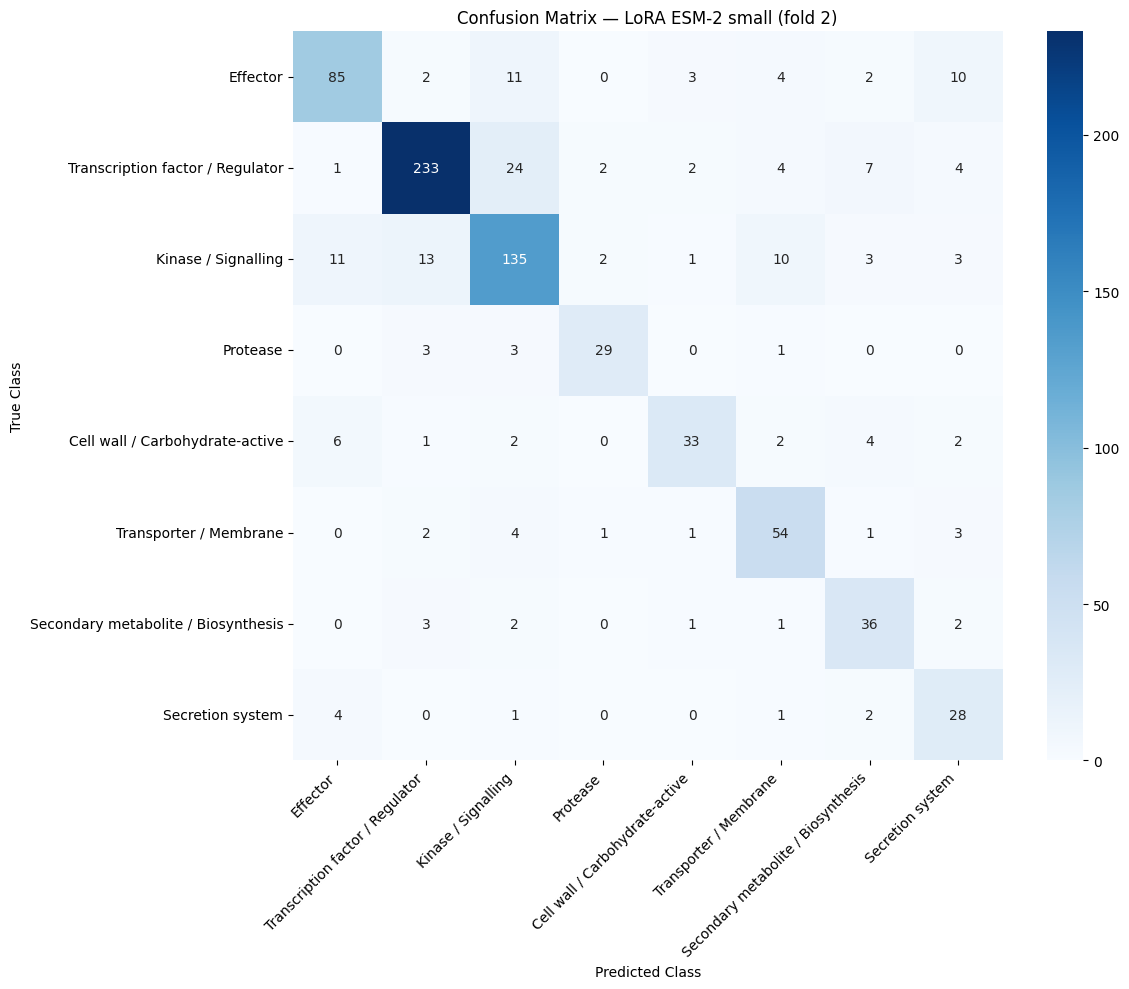

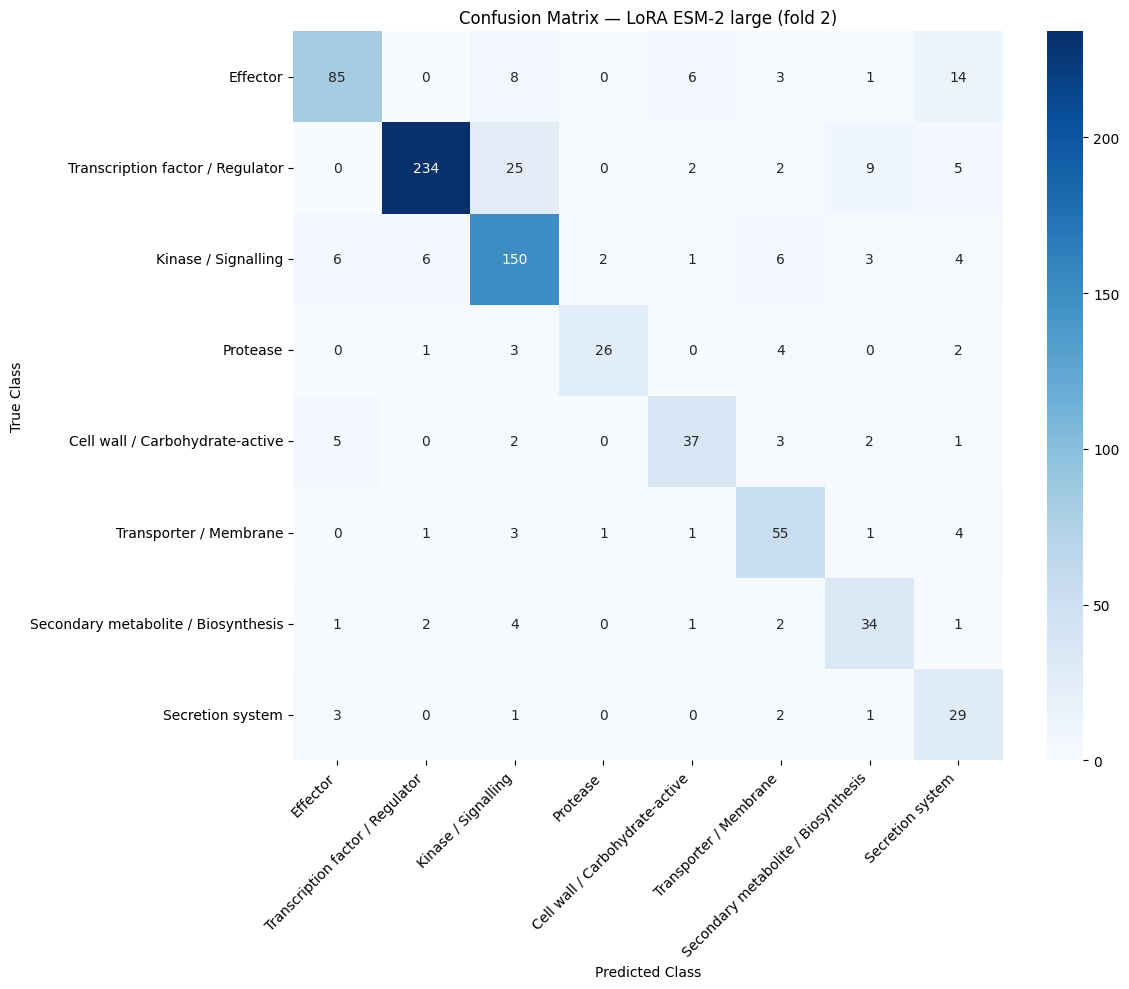

In [16]:
# Confusion matrices — one per model size
for size, ea in error_analysis_lora.items():
    best_fold = best_folds_lora[size]
    fig, ax = plt.subplots(figsize=(12, 10))
    cm = confusion_matrix(ea['val_labels'], ea['val_preds'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names, ax=ax
    )
    ax.set_title(f'Confusion Matrix — LoRA ESM-2 {size} (fold {best_fold+1})')
    ax.set_xlabel('Predicted Class')
    ax.set_ylabel('True Class')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [17]:
# Top-2 prediction analysis
for size, ea in error_analysis_lora.items():
    best_fold   = best_folds_lora[size]
    val_logits  = ea['val_logits']
    val_labels  = ea['val_labels']
    correct     = ea['correct']

    top2             = np.argsort(val_logits, axis=1)[:, ::-1][:, :2]
    top2_correct     = top2[:, 1] == val_labels
    top1_or_top2     = correct | top2_correct
    n_wrong          = (~correct).sum()

    print(f"\nTop-2 analysis — ESM-2 {size} (fold {best_fold+1}):")
    print(f"  Top-1 accuracy:                  {correct.mean()*100:.1f}%")
    print(f"  Top-2 accuracy (either correct): {top1_or_top2.mean()*100:.1f}%")
    print(f"\n  Of the {n_wrong} misclassified sequences:")
    print(f"    2nd guess correct: {top2_correct[~correct].sum()} ({top2_correct[~correct].mean()*100:.1f}%)")
    print(f"    2nd guess wrong:   {(~top2_correct[~correct]).sum()} ({(~top2_correct[~correct]).mean()*100:.1f}%)")
    print(f"    Random chance (1 in 7): 14.3%")

    # Most common confusion patterns
    from collections import Counter
    confusion_pairs = Counter()
    for true, pred1, pred2 in zip(
        val_labels[~correct], top2[~correct, 0], top2[~correct, 1]
    ):
        confusion_pairs[(idx_to_class[true], idx_to_class[pred1], idx_to_class[pred2])] += 1

    print(f"\n  Most common confusion patterns:")
    print(f"  {'True':<35} {'1st guess':<35} {'2nd guess':<35} {'2nd=true?':<10} {'Count'}")
    print("  " + "-" * 120)
    for (true, pred1, pred2), count in confusion_pairs.most_common(10):
        second_correct = "✓" if pred2 == true else "✗"
        print(f"  {true:<35} {pred1:<35} {pred2:<35} {second_correct:<10} {count}")


Top-2 analysis — ESM-2 small (fold 2):
  Top-1 accuracy:                  78.6%
  Top-2 accuracy (either correct): 89.3%

  Of the 172 misclassified sequences:
    2nd guess correct: 86 (50.0%)
    2nd guess wrong:   86 (50.0%)
    Random chance (1 in 7): 14.3%

  Most common confusion patterns:
  True                                1st guess                           2nd guess                           2nd=true?  Count
  ------------------------------------------------------------------------------------------------------------------------
  Transcription factor / Regulator    Kinase / Signalling                 Transcription factor / Regulator    ✓          21
  Kinase / Signalling                 Transcription factor / Regulator    Kinase / Signalling                 ✓          10
  Kinase / Signalling                 Transporter / Membrane              Kinase / Signalling                 ✓          10
  Kinase / Signalling                 Effector                            Kinase


small (fold 2) truncation analysis:
  Truncated (>1022 aa): 44 (5.5%)
  Accuracy on truncated:       97.7%
  Accuracy on full-length:     77.5%

large (fold 2) truncation analysis:
  Truncated (>1022 aa): 44 (5.5%)
  Accuracy on truncated:       97.7%
  Accuracy on full-length:     79.8%


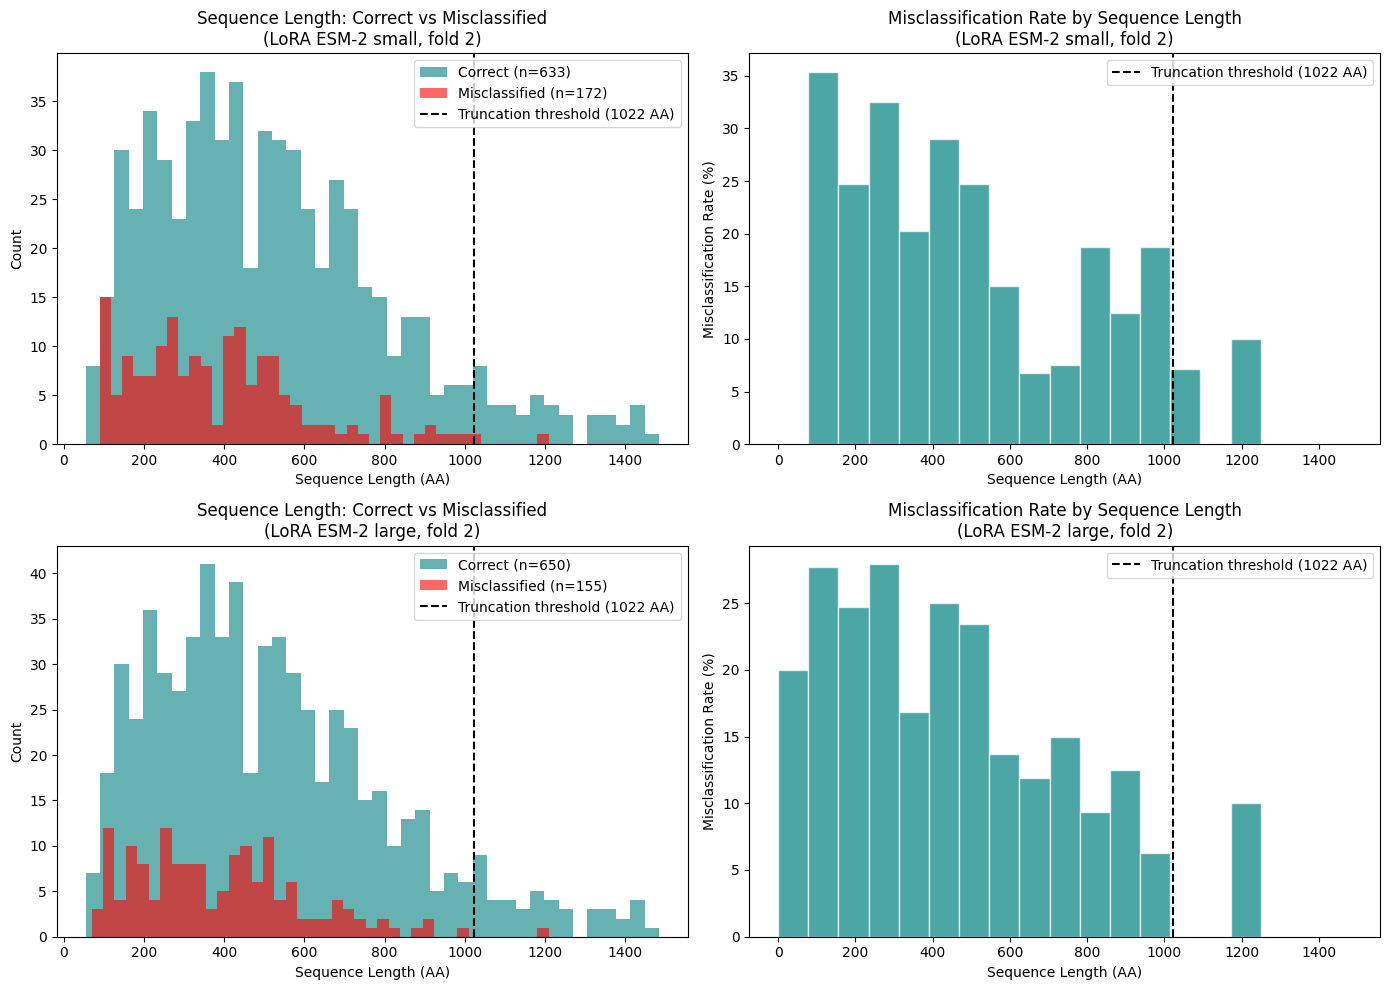

In [18]:
# Truncation analysis — both model sizes side by side
MAX_LEN = model_config['memory']['max_token_length']

fig, axes = plt.subplots(len(error_analysis_lora), 2,
                         figsize=(14, 5 * len(error_analysis_lora)))
if len(error_analysis_lora) == 1:
    axes = [axes]

for row, (size, ea) in enumerate(error_analysis_lora.items()):
    best_fold   = best_folds_lora[size]
    correct     = ea['correct']
    seq_lengths = ea['seq_lengths']
    truncated   = ea['truncated']

    print(f"\n{size} (fold {best_fold+1}) truncation analysis:")
    print(f"  Truncated (>{MAX_LEN-2} aa): {truncated.sum()} ({truncated.mean()*100:.1f}%)")
    print(f"  Accuracy on truncated:       {correct[truncated].mean()*100:.1f}%")
    print(f"  Accuracy on full-length:     {correct[~truncated].mean()*100:.1f}%")

    axes[row][0].hist(seq_lengths[correct],  bins=40, alpha=0.6, color='teal',
                      label=f'Correct (n={correct.sum()})')
    axes[row][0].hist(seq_lengths[~correct], bins=40, alpha=0.6, color='red',
                      label=f'Misclassified (n={(~correct).sum()})')
    axes[row][0].axvline(x=MAX_LEN-2, color='black', linestyle='--',
                         label=f'Truncation threshold ({MAX_LEN-2} AA)')
    axes[row][0].set_title(f'Sequence Length: Correct vs Misclassified\n(LoRA ESM-2 {size}, fold {best_fold+1})')
    axes[row][0].set_xlabel('Sequence Length (AA)')
    axes[row][0].set_ylabel('Count')
    axes[row][0].legend()

    bin_edges   = np.linspace(0, seq_lengths.max(), 20)
    bin_indices = np.digitize(seq_lengths, bin_edges)
    bin_error_rates, bin_centres = [], []
    for b in range(1, len(bin_edges)):
        mask = bin_indices == b
        if mask.sum() >= 5:
            bin_error_rates.append((~correct[mask]).mean() * 100)
            bin_centres.append((bin_edges[b-1] + bin_edges[b]) / 2)

    axes[row][1].bar(bin_centres, bin_error_rates,
                     width=bin_edges[1]-bin_edges[0],
                     color='teal', alpha=0.7, edgecolor='white')
    axes[row][1].axvline(x=MAX_LEN-2, color='black', linestyle='--',
                         label=f'Truncation threshold ({MAX_LEN-2} AA)')
    axes[row][1].set_title(f'Misclassification Rate by Sequence Length\n(LoRA ESM-2 {size}, fold {best_fold+1})')
    axes[row][1].set_xlabel('Sequence Length (AA)')
    axes[row][1].set_ylabel('Misclassification Rate (%)')
    axes[row][1].legend()

plt.tight_layout()
plt.show()

In [19]:
# Fragment analysis — short sequences (<100 AA)
FRAGMENT_THRESHOLD = 100

for size, ea in error_analysis_lora.items():
    best_fold   = best_folds_lora[size]
    correct     = ea['correct']
    seq_lengths = ea['seq_lengths']
    fragment    = seq_lengths < FRAGMENT_THRESHOLD

    print(f"{size} (fold {best_fold+1}) fragment analysis:")
    print(f"  Fragments (<{FRAGMENT_THRESHOLD} AA):  {fragment.sum()} ({fragment.mean()*100:.1f}%)")
    if fragment.sum() > 0:
        print(f"  Accuracy on fragments:     {correct[fragment].mean()*100:.1f}%")
    print(f"  Accuracy on ≥{FRAGMENT_THRESHOLD} AA:       {correct[~fragment].mean()*100:.1f}%\n")

small (fold 2) fragment analysis:
  Fragments (<100 AA):  16 (2.0%)
  Accuracy on fragments:     68.8%
  Accuracy on ≥100 AA:       78.8%

large (fold 2) fragment analysis:
  Fragments (<100 AA):  16 (2.0%)
  Accuracy on fragments:     68.8%
  Accuracy on ≥100 AA:       81.0%



## 6 Model Saving

This section saves the LoRA adapters, classification head weights, tokenizers, and a deployment config for both ESM-2 variants. Models are saved per fold — the best fold per model size is additionally copied to a `best/` subdirectory for convenient deployment.

In [20]:
import json
import shutil

deployment_dir = os.path.join(output_dir, "deployment")
os.makedirs(deployment_dir, exist_ok=True)

for size, res in lora_results.items():
    best_fold      = best_folds_lora[size]
    fold_save_path = res['best_params'][best_fold]

    best_deploy_dir = os.path.join(deployment_dir, f"best_{size}")
    os.makedirs(best_deploy_dir, exist_ok=True)

    # Copy LoRA adapter + classifier head into deployment directory
    for fname in ["adapter_config.json", "adapter_model.safetensors", "classifier_head.pt"]:
        src = os.path.join(fold_save_path, fname)
        if os.path.exists(src):
            shutil.copy2(src, best_deploy_dir)

    # Save deployment config
    deployment_config = {
        "model": {
            "size":        size,
            "base_model":  model_config['model']['models'][size],
            "hidden_dim":  model_config['model']['hidden_dims'][size],
            "num_classes": model_config['model']['num_classes'],
            "layer_1_dim": model_config['classification_head']['layer_1_dim'],
            "layer_2_dim": model_config['classification_head']['layer_2_dim'],
            "dropout_rate": model_config['model']['dropout_rate'],
            "pooling":     model_config['classification_head']['pooling']
        },
        "lora": {
            "rank":           training_config['lora']['rank'],
            "alpha":          training_config['lora']['alpha'],
            "dropout":        training_config['lora']['dropout'],
            "target_modules": training_config['lora']['target_modules'],
            "bias":           training_config['lora']['bias']
        },
        "training": {
            "learning_rate":               training_config['training']['learning_rate'],
            "num_epochs":                  training_config['training']['num_epochs'],
            "batch_size":                  training_config['training']['per_device_train_batch_size'],
            "gradient_accumulation_steps": training_config['training']['gradient_accumulation_steps'],
            "warmup_ratio":                training_config['training']['warmup_ratio'],
            "lr_scheduler_type":           training_config['training']['lr_scheduler_type'],
            "k_folds":                     training_config['training']['k_folds'],
            "best_fold":                   best_fold + 1,
            "class_weighting":             True
        },
        "label_mapping": data_config['target_mapping'],
        "performance": {
            "frozen_baseline_macro_f1": {'small': 0.698, 'large': 0.733}[size],
            "lora_mean_macro_f1":       round(float(res['mean_f1']), 4),
            "lora_std_macro_f1":        round(float(res['std_f1']), 4),
            "lora_best_fold_macro_f1":  round(float(res['fold_f1s'][best_fold]), 4),
            "improvement":              round(float(res['mean_f1']) - {'small': 0.698, 'large': 0.733}[size], 4)
        },
        "dataset": {
            "source":     "PHI-base",
            "train_seqs": len(df_train),
            "test_seqs":  len(df_test),
            "split":      "90/10 train/test, 5-fold CV within train"
        }
    }

    config_path = os.path.join(best_deploy_dir, "deployment_config.json")
    with open(config_path, 'w') as f:
        json.dump(deployment_config, f, indent=2)

    # Upload deployment artifacts to GCS
    gcs_deploy_prefix = f"{GCS_PREFIX}/deployment/best_{size}"
    upload_dir_to_gcs(best_deploy_dir, gcs_deploy_prefix)

    print(f"\n{size} deployment saved to: gs://{GCS_BUCKET}/{gcs_deploy_prefix}/")
    print(json.dumps(deployment_config, indent=2))

print("\nAll models saved to GCS.")

  ↑ Uploaded /content/lora_output/deployment/best_small → gs://esm-phi-checkpoints/lora_checkpoints/deployment/best_small/

small deployment saved to: gs://esm-phi-checkpoints/lora_checkpoints/deployment/best_small/
{
  "model": {
    "size": "small",
    "base_model": "facebook/esm2_t30_150M_UR50D",
    "hidden_dim": 640,
    "num_classes": 8,
    "layer_1_dim": 256,
    "layer_2_dim": 128,
    "dropout_rate": 0.1,
    "pooling": "mean"
  },
  "lora": {
    "rank": 8,
    "alpha": 16,
    "dropout": 0.1,
    "target_modules": [
      "query",
      "key",
      "value",
      "dense"
    ],
    "bias": "none"
  },
  "training": {
    "learning_rate": 0.0002,
    "num_epochs": 20,
    "batch_size": 8,
    "gradient_accumulation_steps": 2,
    "warmup_ratio": 0.1,
    "lr_scheduler_type": "cosine",
    "k_folds": 5,
    "best_fold": 2,
    "class_weighting": true
  },
  "label_mapping": {
    "Effector": 0,
    "Transcription factor / Regulator": 1,
    "Kinase / Signalling": 2,
    "Pr

## 7 Takeaways

**LoRA fine-tuning delivers a clear improvement over frozen baselines.** The small model improved from 0.698 → 0.756 macro F1 (+0.058) and the large model from 0.733 → 0.765 (+0.032). Both models now exceed 78% top-1 accuracy on 8-class classification from sequence alone.

**The large model gains less from fine-tuning than the small model.** The 650M model's frozen representations were already better organised for this task, leaving less room for LoRA to improve. The small model closed most of the gap, suggesting LoRA is particularly cost-effective on smaller encoders.

**Boundary ambiguity remains the dominant error mode.** Top-2 accuracy reaches ~89% for both models (vs ~79–81% top-1), with 46–50% of misclassifications having the correct class as the second prediction — far above the 14.3% random baseline. The most persistent confusion axis is Transcription factor / Regulator ↔ Kinase / Signalling (21 cases in both models), which likely reflects genuine biological overlap between signalling kinases and transcriptional regulators in pathogen virulence cascades.

**Effector ↔ Secretion system confusion is structurally expected.** Effectors are delivered by secretion systems, so sequence-level similarity between these classes reflects real biological coupling rather than model failure. This was the second most common confusion pattern for both model sizes.

**Truncation is not a meaningful source of error.** Only 5.5% of sequences exceed the 1022 AA token limit, and accuracy on truncated sequences is actually *higher* (97.7%) than on full-length sequences (~78–80%). This likely reflects the class composition of long sequences rather than truncation being beneficial — long proteins in this dataset tend to belong to well-separated classes.

**Short fragments deserve monitoring but are a small fraction.** Accuracy on fragments below 100 AA should be checked as these sequences carry less signal, though they make up a small proportion of the dataset.

**Remaining errors likely reflect annotation ambiguity in PHI-bas